In [1]:
import pandas as pd
borough= pd.read_csv(r"C:\Jason\Ride share project\taxi_zone_lookup.csv")
print(borough.shape)
cols = ['hvfhs_license_num',
        'request_datetime', 
        'trip_miles',
        'trip_time', #in seconds
        'PULocationID', 
        'DOLocationID',
        'congestion_surcharge', 
        'shared_request_flag']
uber_df = pd.read_parquet(r"C:\Jason\Ride share project\fhvhv_tripdata_2025-01.parquet", columns=cols)
uber_df = uber_df[uber_df['hvfhs_license_num'] == 'HV0003'].copy()
print(uber_df.shape)
uber_df.head()


(265, 4)
(15356455, 8)


,hvfhs_license_num,request_datetime,trip_miles,trip_time,PULocationID,DOLocationID,congestion_surcharge,shared_request_flag
0,HV0003,2025-01-01 00:28:07,1.32,1259,148,211,2.75,N
2,HV0003,2025-01-01 00:28:22,13.43,2874,132,181,0.00,N
3,HV0003,2025-01-01 00:27:13,0.82,264,76,76,0.00,N
4,HV0003,2025-01-01 00:33:29,1.61,457,76,76,0.00,N
5,HV0003,2025-01-01 00:34:43,9.66,2073,112,89,0.00,N


In [2]:
print(borough.columns.tolist())
print(borough.head())


['LocationID', 'Borough', 'Zone', 'service_zone']
   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone


In [3]:
#merge pickup borough
uber_df = uber_df.merge(borough[['LocationID', 'Borough', 'Zone']], 
                        left_on='PULocationID', right_on='LocationID', how='left')
uber_df.rename(columns={'Borough': 'PU_Borough', 
                        'Zone': 'PU_Zone', 
                        'LocationID': 'PU_LocationID'}, 
               inplace=True)
#merge dropoff locations
uber_df = uber_df.merge(borough[['LocationID', 'Borough', 'Zone']], 
                        left_on='DOLocationID', right_on='LocationID', how='left')
uber_df.rename(columns={'Borough': 'DO_Borough', 
                        'Zone': 'DO_Zone', 
                        'LocationID': 'DO_LocationID'}, 
               inplace=True)

In [4]:
uber_df = uber_df[(uber_df['trip_miles']>0.1)
                   & (uber_df['trip_time']>60)&
                      (uber_df['trip_miles']<100)].copy()
uber_df.head()

,hvfhs_license_num,request_datetime,trip_miles,trip_time,PULocationID,DOLocationID,congestion_surcharge,shared_request_flag,PU_LocationID,PU_Borough,PU_Zone,DO_LocationID,DO_Borough,DO_Zone
0,HV0003,2025-01-01 00:28:07,1.32,1259,148,211,2.75,N,148,Manhattan,Lower East Side,211,Manhattan,SoHo
1,HV0003,2025-01-01 00:28:22,13.43,2874,132,181,0.00,N,132,Queens,JFK Airport,181,Brooklyn,Park Slope
2,HV0003,2025-01-01 00:27:13,0.82,264,76,76,0.00,N,76,Brooklyn,East New York,76,Brooklyn,East New York
3,HV0003,2025-01-01 00:33:29,1.61,457,76,76,0.00,N,76,Brooklyn,East New York,76,Brooklyn,East New York
4,HV0003,2025-01-01 00:34:43,9.66,2073,112,89,0.00,N,112,Brooklyn,Greenpoint,89,Brooklyn,Flatbush/Ditmas Park


In [5]:
#Time Bucket, day of week, weekend flag
#drives at different times of the day will have different patterns, so we can bucket the time into bands (e.g., morning, afternoon, evening) and also identify if it's a weekend or not.
uber_df['hour'] = uber_df['request_datetime'].dt.hour
uber_df['day_of_week'] = uber_df['request_datetime'].dt.dayofweek
uber_df['is_weekend'] = uber_df['day_of_week'].isin([4,5,6]).astype(int)

#bands
def time_band(hour):
    if 0 <= hour < 6:
        return 'Late Night'
    elif 6 <= hour < 10:
        return 'Morning'
    elif 10 <= hour < 16:
        return 'Midday'
    elif 16 <= hour < 20:
        return 'Evening'
    else:
        return 'Night'
uber_df['time_band'] = uber_df['hour'].apply(time_band)
print(uber_df[['hour', 'time_band']].head())

   hour   time_band
0     0  Late Night
1     0  Late Night
2     0  Late Night
3     0  Late Night
4     0  Late Night


In [6]:
uber_df['avg_speed_mph'] = uber_df['trip_miles'] / (uber_df['trip_time'] / 3600)#average speed in miles per hour
uber_df['trip_time_minutes'] = uber_df['trip_time'] / 60#trip time in minutes

In [7]:
uber_df['exposure'] = uber_df['trip_miles'] #how far the drive is
uber_df['avg_speed_mph'] = uber_df['trip_miles'] / (uber_df['trip_time'] / 3600) #average speed in miles per hour
uber_df['highway_flag'] = (uber_df['avg_speed_mph'] > 45).astype(int) #assuming trips with avg speed > 45 mph are likely on highways

In [8]:
#trip value by time buckets
time_stats = uber_df.groupby('time_band').agg(
    trip_count = ('trip_miles', 'count'),
    avg_miles = ('trip_miles', 'mean'),
    total_miles = ('trip_miles', 'sum'),
    avg_speed = ('avg_speed_mph', 'mean')).reset_index()
time_stats['pct_of_trips'] = time_stats['trip_count'] / time_stats['trip_count'].sum() * 100
print(time_stats.round(2))                                       

    time_band  trip_count  avg_miles  total_miles  avg_speed  pct_of_trips
0     Evening     3648967       4.47  16319908.48      12.40         23.77
1  Late Night     1766039       5.89  10398095.19      18.03         11.51
2      Midday     4256519       4.79  20388406.48      13.12         27.73
3     Morning     2644871       4.86  12854500.36      14.11         17.23
4       Night     3032476       5.29  16056242.29      15.48         19.76


In [9]:
#trips between boroughs to see which routes are common, which are more likely to be taken etc.
borough_stats = uber_df.groupby(['PU_Borough', 'DO_Borough']).agg(
    trip_count = ('trip_miles', 'count'),
    avg_miles = ('trip_miles', 'mean'),
    total_miles = ('trip_miles', 'sum'),
    avg_speed = ('avg_speed_mph', 'mean')).reset_index()
borough_stats['pct_of_trips'] = borough_stats['trip_count'] / borough_stats['trip_count'].sum() * 100
borough_stats = borough_stats.sort_values('trip_count', ascending=False)

print(borough_stats[['PU_Borough', 'DO_Borough', 'trip_count', 'pct_of_trips']].round(2))


       PU_Borough     DO_Borough  trip_count  pct_of_trips
16      Manhattan      Manhattan     4001057         27.20
7        Brooklyn       Brooklyn     3154499         21.44
23         Queens         Queens     2127013         14.46
0           Bronx          Bronx     1527405         10.38
17      Manhattan         Queens      508904          3.46
14      Manhattan       Brooklyn      478401          3.25
22         Queens      Manhattan      464396          3.16
9        Brooklyn      Manhattan      418565          2.85
10       Brooklyn         Queens      399441          2.72
20         Queens       Brooklyn      386775          2.63
13      Manhattan          Bronx      353138          2.40
3           Bronx      Manhattan      334955          2.28
30  Staten Island  Staten Island      203467          1.38
15      Manhattan            EWR       81829          0.56
4           Bronx         Queens       72670          0.49
19         Queens          Bronx       70436          0.

In [10]:
#highway marker
speed_stats = uber_df.groupby('highway_flag').agg(
    trip_count = ('trip_miles', 'count'),
    avg_miles = ('trip_miles', 'mean'),
    total_miles = ('trip_miles', 'sum'),
    avg_speed = ('avg_speed_mph', 'mean'),).reset_index()
    
speed_stats['highway_flag'] = speed_stats['highway_flag'].map({0: 'city', 1: 'highway'})
print(speed_stats.round(2))

  highway_flag  trip_count  avg_miles  total_miles  avg_speed
0         city    15315159       4.87   74618549.3      14.07
1      highway       33713      41.49    1398603.5      48.34


In [13]:
print(uber_df.columns.tolist())
print(borough_stats.columns.tolist())

['hvfhs_license_num', 'request_datetime', 'trip_miles', 'trip_time', 'PULocationID', 'DOLocationID', 'congestion_surcharge', 'shared_request_flag', 'PU_LocationID', 'PU_Borough', 'PU_Zone', 'DO_LocationID', 'DO_Borough', 'DO_Zone', 'hour', 'day_of_week', 'is_weekend', 'time_band', 'avg_speed_mph', 'trip_time_minutes', 'exposure', 'highway_flag']
['PU_Borough', 'DO_Borough', 'trip_count', 'avg_miles', 'total_miles', 'avg_speed', 'pct_of_trips']


Text(0, 0.5, 'Trip count')

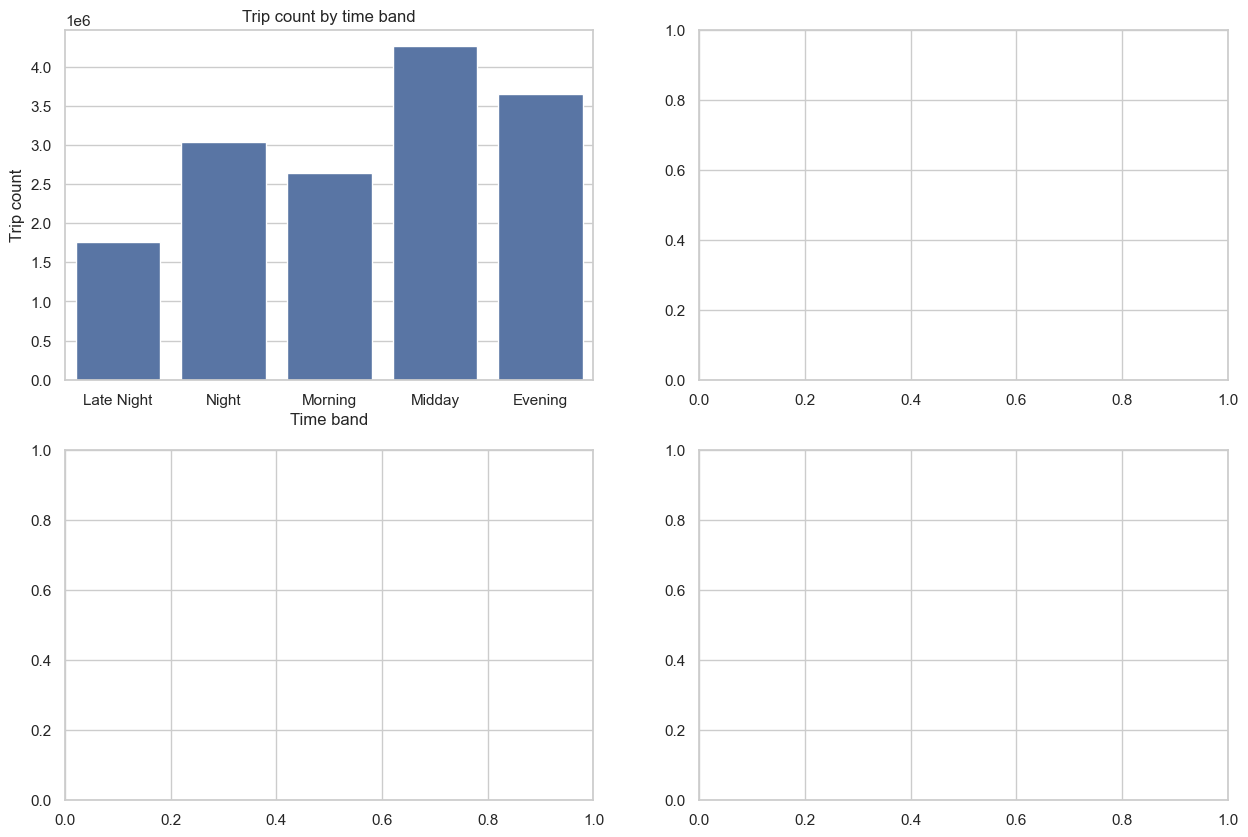

In [14]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.countplot(data=uber_df, x='time_band', ax=axes[0,0])
axes[0,0].set_title('Trip count by time band')
axes[0,0].set_xlabel('Time band')
axes[0,0].set_ylabel('Trip count')
